# 单因子分析 — 动量因子 (mom_20d)

单因子研究的标准流程：**因子分布 → IC 分析 → 分层收益 → 多空收益 → 稳定性**。

当前用 mock 数据验证流程，切换真实数据只需替换数据加载部分。

In [1]:
from pathlib import Path
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

# ── matplotlib / seaborn 全局样式 ──
sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "figure.titlesize": 13,
    "legend.fontsize": 9,
})
C = sns.color_palette("colorblind")

# ── 配置 ──
FACTOR_WINDOW = 20
FORWARD_HORIZONS = [1, 5, 20]
N_QUANTILES = 5
RNG = np.random.default_rng(42)
N_DATES, N_STOCKS = 200, 100


In [2]:
# ── Mock 数据生成 ──
def make_mock_data(n_dates=N_DATES, n_stocks=N_STOCKS):
    dates = pd.bdate_range("2022-01-03", periods=n_dates)
    industries = np.array(["电子", "医药", "银行", "机械", "消费"])
    
    codes = []
    for i in range(n_stocks):
        if i < n_stocks // 2:
            codes.append(f"{600000 + i:06d}.SH")
        else:
            codes.append(f"{300000 + i - n_stocks // 2:06d}.SZ")
    
    ind_map = RNG.choice(industries, n_stocks)
    size_base = RNG.lognormal(mean=3.2, sigma=0.8, size=n_stocks)
    
    frames = []
    for i, code in enumerate(codes):
        eps = RNG.normal(0, 0.016, n_dates)
        ret = np.zeros(n_dates)
        ret[0] = eps[0]
        for t in range(1, n_dates):
            ret[t] = 0.05 * ret[t-1] + eps[t]
        drift = RNG.normal(0, 0.0004)
        price = 10.0 * np.exp(np.cumsum(ret + drift))
        mv = price * size_base[i] * 1e8
        
        df = pd.DataFrame({
            "trade_date": dates,
            "ts_code": code,
            "close": price,
            "total_mv": mv,
            "is_suspended": False,
            "sw_l1_name": ind_map[i],
        })
        frames.append(df)
    
    panel = pd.concat(frames, ignore_index=True)
    n = len(panel)
    panel.loc[RNG.choice(n, n // 120, replace=False), "is_suspended"] = True
    panel.loc[RNG.choice(n, n // 100, replace=False), "close"] = np.nan
    panel.loc[RNG.choice(n, n // 80, replace=False), "total_mv"] = np.nan
    return panel.sort_values(["trade_date", "ts_code"]).reset_index(drop=True)


df = make_mock_data()
print(f"{len(df):,} rows x {df.ts_code.nunique()} stocks x {df.trade_date.nunique()} dates")


20,000 rows x 100 stocks x 200 dates


In [3]:
# ── 因子计算 pipeline ──
def compute_momentum(df, window=20):
    df = df.sort_values(["ts_code", "trade_date"]).copy()
    df["mom_20d"] = df.groupby("ts_code")["close"].transform(
        lambda s: s / s.shift(window) - 1)
    return df

def compute_forward_returns(df, horizons=(1, 5, 20)):
    df = df.sort_values(["ts_code", "trade_date"]).copy()
    for h in horizons:
        df[f"fwd_{h}d"] = df.groupby("ts_code")["close"].transform(
            lambda s: s.shift(-(h + 1)) / s.shift(-1) - 1)
    return df

def winsorize_mad(series, n=3.0):
    med, mad = series.median(), (series - series.median()).abs().median()
    if pd.isna(mad) or mad == 0:
        return series
    scale = n * 1.4826 * mad
    return series.clip(med - scale, med + scale)

def cross_sectional_zscore(series):
    std = series.std(ddof=0)
    return (series - series.mean()) / std if std > 0 else pd.Series(0.0, index=series.index)

def neutralize_by_size(df, factor_col):
    df = df.copy()
    df["factor_neutral"] = np.nan
    for _, g in df.groupby("trade_date"):
        mask = g["total_mv"].notna() & g["total_mv"].gt(0) & g[factor_col].notna()
        if mask.sum() < 5:
            continue
        x = np.log(g.loc[mask, "total_mv"].values)
        y = g.loc[mask, factor_col].values
        beta = np.linalg.lstsq(np.column_stack([np.ones(len(x)), x]), y, rcond=None)[0]
        resid = y - np.column_stack([np.ones(len(x)), x]) @ beta
        resid = (resid - resid.mean()) / resid.std(ddof=0)
        df.loc[g.index[mask], "factor_neutral"] = resid
    return df

def assign_quantiles(df, factor_col, n_quantiles=5):
    df = df.copy()
    df["quantile"] = pd.NA
    for _, g in df.groupby("trade_date"):
        mask = g[factor_col].notna()
        if mask.sum() < n_quantiles:
            continue
        df.loc[g.index[mask], "quantile"] = pd.qcut(
            g.loc[mask, factor_col].rank(method="first"),
            q=n_quantiles, labels=range(1, n_quantiles + 1))
    return df.astype({"quantile": "Int64"})


# 执行 pipeline
df = compute_momentum(df, FACTOR_WINDOW)
df = compute_forward_returns(df, FORWARD_HORIZONS)

# 筛选有效样本
valid = (df["close"].notna() & ~df["is_suspended"]
         & df["total_mv"].notna() & df["total_mv"].gt(0)
         & df["mom_20d"].notna() & df["fwd_20d"].notna())
df["universe"] = valid

# 因子预处理: winsorize -> zscore -> size-neutral
df["factor_raw"] = df.groupby("trade_date")["mom_20d"].transform(winsorize_mad)
df["factor_zscore"] = df.groupby("trade_date")["factor_raw"].transform(cross_sectional_zscore)
df = neutralize_by_size(df, "factor_zscore")

# 基于中性化因子分组
df = assign_quantiles(df, "factor_neutral", N_QUANTILES)

FACTOR_COL = "factor_neutral"
FWD_COL = "fwd_5d"

print(f"有效样本: {df.universe.sum():,} / {len(df):,} rows")
display(df[df.universe][['trade_date', 'ts_code', 'mom_20d', 'factor_raw',
                           'factor_zscore', 'factor_neutral', 'quantile']].head(8))


有效样本: 14,983 / 20,000 rows


,trade_date,ts_code,mom_20d,factor_raw,factor_zscore,factor_neutral,quantile
2000,2022-01-31,300000.SZ,-0.0977,-0.0977,-1.3078,-1.3633,1
2100,2022-02-01,300000.SZ,-0.0820,-0.0820,-1.1726,-1.1976,1
2200,2022-02-02,300000.SZ,-0.0342,-0.0342,-0.5462,-0.6358,2
2300,2022-02-03,300000.SZ,-0.0476,-0.0476,-0.7320,-0.8238,1
2400,2022-02-04,300000.SZ,-0.0542,-0.0542,-0.7751,-0.8649,1
2500,2022-02-07,300000.SZ,-0.0181,-0.0181,-0.2980,-0.3466,2
2600,2022-02-08,300000.SZ,-0.0486,-0.0486,-0.7027,-0.7761,2
2900,2022-02-11,300000.SZ,-0.0699,-0.0699,-0.8928,-0.9557,1


---
## 1. 因子分布

看三件事：**原始分布是否有极端值、标准化后是否适合截面比较、中性化后是否保留足够离散度**。

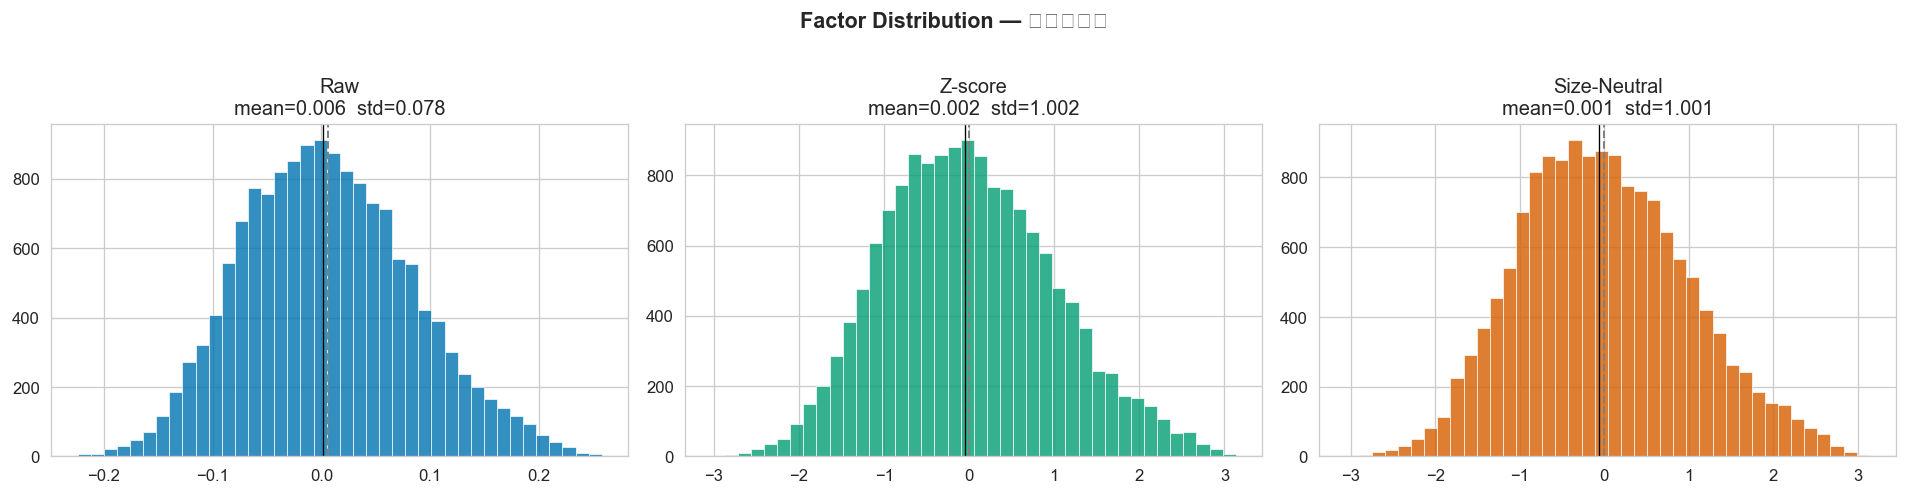

,count,mean,std,skew,p01,p99
version,,,,,,
Raw,14983,0.0059,0.0781,0.2435,-0.1564,0.1972
Z-score,14983,0.0024,1.0017,0.2687,-2.0358,2.4908
Size-Neutral,14983,0.0006,1.0010,0.2606,-2.0491,2.4674


In [4]:
sample = df[df.universe]
labels = ["Raw", "Z-score", "Size-Neutral"]
cols = ["factor_raw", "factor_zscore", "factor_neutral"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col, label, clr in zip(axes, cols, labels, [C[0], C[2], C[3]]):
    vals = sample[col].dropna()
    ax.hist(vals, bins=40, color=clr, alpha=0.8, edgecolor="white", linewidth=0.5)
    ax.axvline(vals.mean(), color="gray", linestyle="--", linewidth=1.2)
    ax.axvline(vals.median(), color="black", linestyle="-", linewidth=0.8)
    ax.set_title(f"{label}\nmean={vals.mean():.3f}  std={vals.std():.3f}")

fig.suptitle("Factor Distribution — 横截面分布", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# 统计表
stats = []
for col, label in zip(cols, labels):
    v = sample[col].dropna()
    stats.append({"version": label, "count": len(v), "mean": v.mean(), "std": v.std(),
                  "skew": v.skew(), "p01": v.quantile(0.01), "p99": v.quantile(0.99)})
display(pd.DataFrame(stats).set_index("version"))


---
## 2. IC 分析

Rank IC = 因子排序与未来收益排序的 Spearman 相关系数。**判断因子有没有横截面预测力的第一关**。

看四个指标：**mean IC 方向、胜率、ICIR、累计 IC 是否趋势向上**。

,mean_ic,std_ic,ic_ir,win_rate,n_days
horizon,,,,,
1d,0.0176,0.1080,0.1632,0.5409,159
5d,0.0320,0.1099,0.2914,0.5975,159
20d,0.0463,0.0938,0.4943,0.6855,159


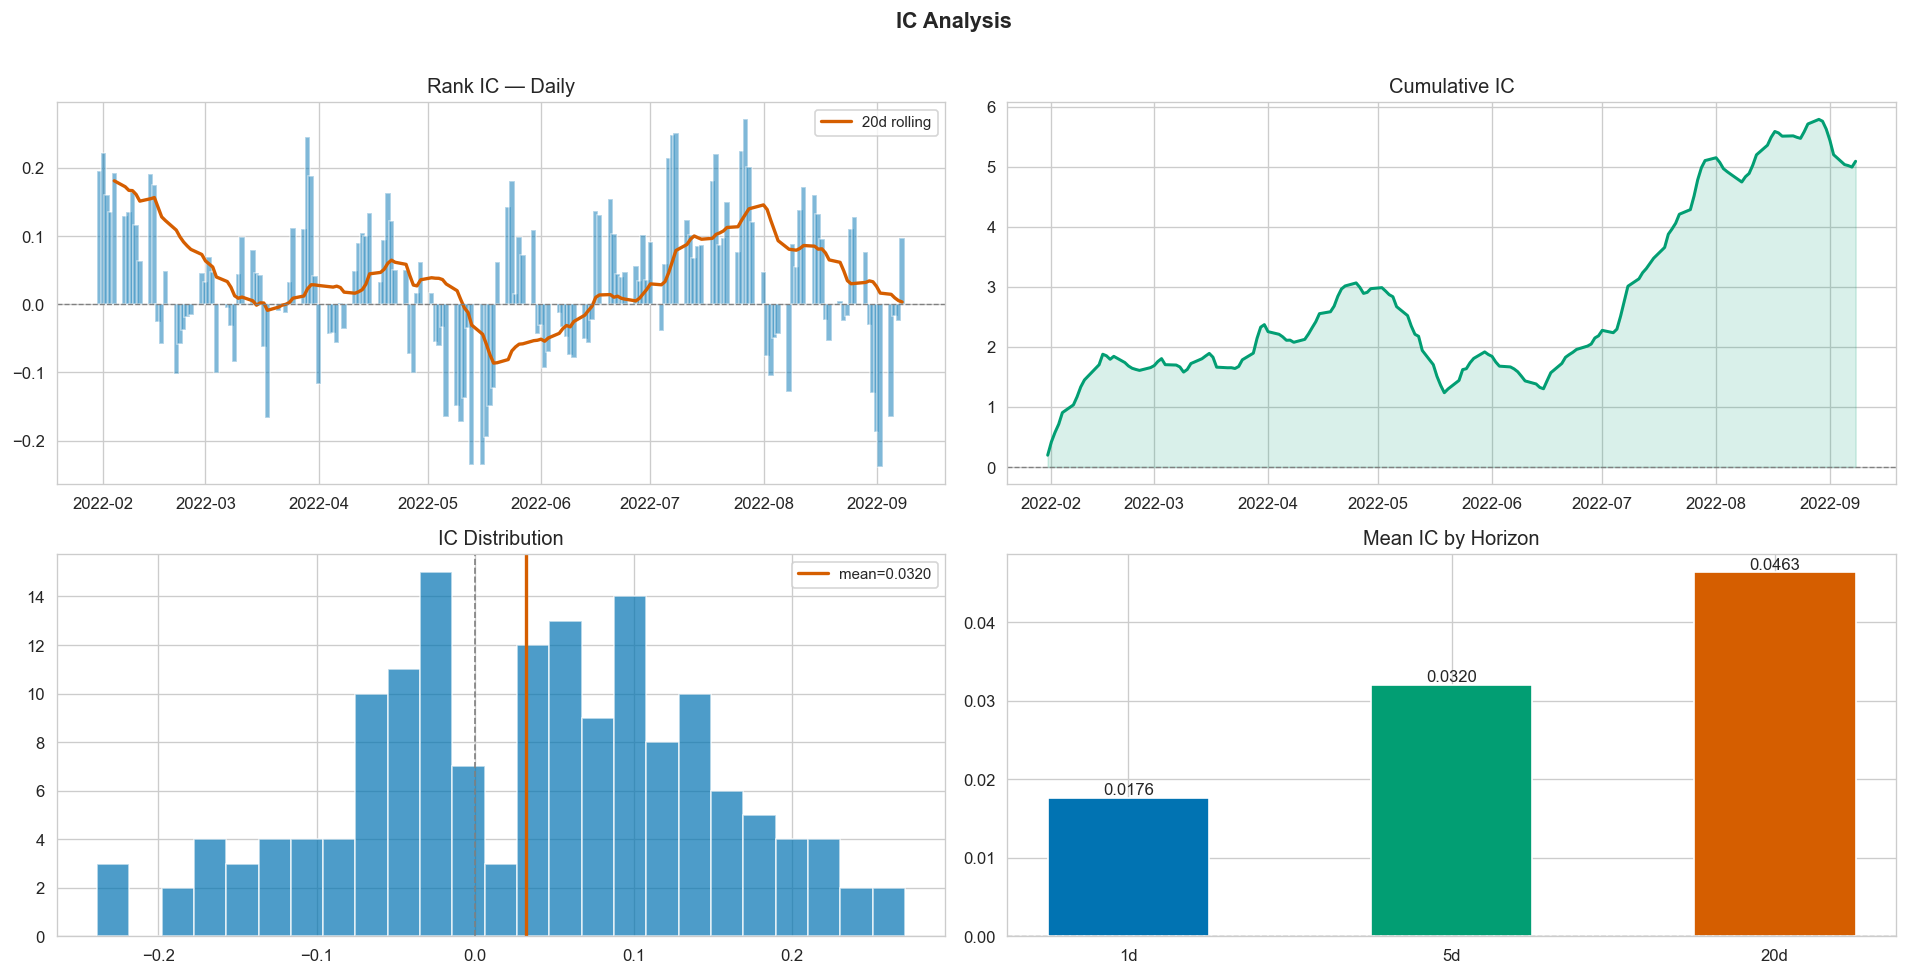

In [5]:
# ── 计算 Rank IC ──
def compute_ic(df, factor_col, fwd_col):
    records = []
    for dt, g in df[df.universe].groupby("trade_date"):
        valid = g[[factor_col, fwd_col]].dropna()
        if len(valid) < 10:
            continue
        ic = valid[factor_col].rank().corr(valid[fwd_col].rank())
        records.append({"trade_date": dt, "rank_ic": ic})
    return pd.DataFrame(records).sort_values("trade_date").reset_index(drop=True)

# 计算多个 horizon 的 IC
ic_frames = {}
for h in FORWARD_HORIZONS:
    ic_frames[h] = compute_ic(df, FACTOR_COL, f"fwd_{h}d")

ic_df = ic_frames[5]  # 主 horizon
ic_df["cum_ic"] = ic_df["rank_ic"].cumsum()
ic_df["rolling_20"] = ic_df["rank_ic"].rolling(20, min_periods=5).mean()

# 统计表
ic_stats = []
for h in FORWARD_HORIZONS:
    ic = ic_frames[h]["rank_ic"].dropna()
    ic_stats.append({
        "horizon": f"{h}d", "mean_ic": ic.mean(), "std_ic": ic.std(),
        "ic_ir": ic.mean() / ic.std() if ic.std() > 0 else np.nan,
        "win_rate": (ic > 0).mean(), "n_days": len(ic)
    })
display(pd.DataFrame(ic_stats).set_index("horizon"))

# ── 图表 ──
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

# IC 时间序列
ax = axes[0, 0]
ax.bar(ic_df["trade_date"], ic_df["rank_ic"], color=C[0], alpha=0.5, width=1.5)
ax.plot(ic_df["trade_date"], ic_df["rolling_20"], color=C[3], linewidth=2, label="20d rolling")
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_title("Rank IC — Daily")
ax.legend()

# 累计 IC
ax = axes[0, 1]
ax.plot(ic_df["trade_date"], ic_df["cum_ic"], color=C[2], linewidth=1.8)
ax.fill_between(ic_df["trade_date"], 0, ic_df["cum_ic"], color=C[2], alpha=0.15)
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_title("Cumulative IC")

# IC 分布直方图
ax = axes[1, 0]
ax.hist(ic_df["rank_ic"], bins=25, color=C[0], alpha=0.7, edgecolor="white")
ax.axvline(0, color="gray", linestyle="--", linewidth=1)
ax.axvline(ic_df["rank_ic"].mean(), color=C[3], linewidth=2,
           label=f'mean={ic_df["rank_ic"].mean():.4f}')
ax.set_title("IC Distribution")
ax.legend()

# 多 horizon IC 对比
ax = axes[1, 1]
x = np.arange(len(FORWARD_HORIZONS))
means = [ic_frames[h]["rank_ic"].mean() for h in FORWARD_HORIZONS]
bars = ax.bar(x, means, color=[C[0], C[2], C[3]], width=0.5)
ax.bar_label(bars, fmt="%.4f")
ax.set_xticks(x)
ax.set_xticklabels([f"{h}d" for h in FORWARD_HORIZONS])
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_title("Mean IC by Horizon")

fig.suptitle("IC Analysis", fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


---
## 3. 分层收益

把每日截面按因子值分成 5 组，看 **高分组未来收益是否系统性高于低分组**。

IC 是"排序相关性"证据，分层收益是"**经济解释**"证据 — **核心看单调性**。

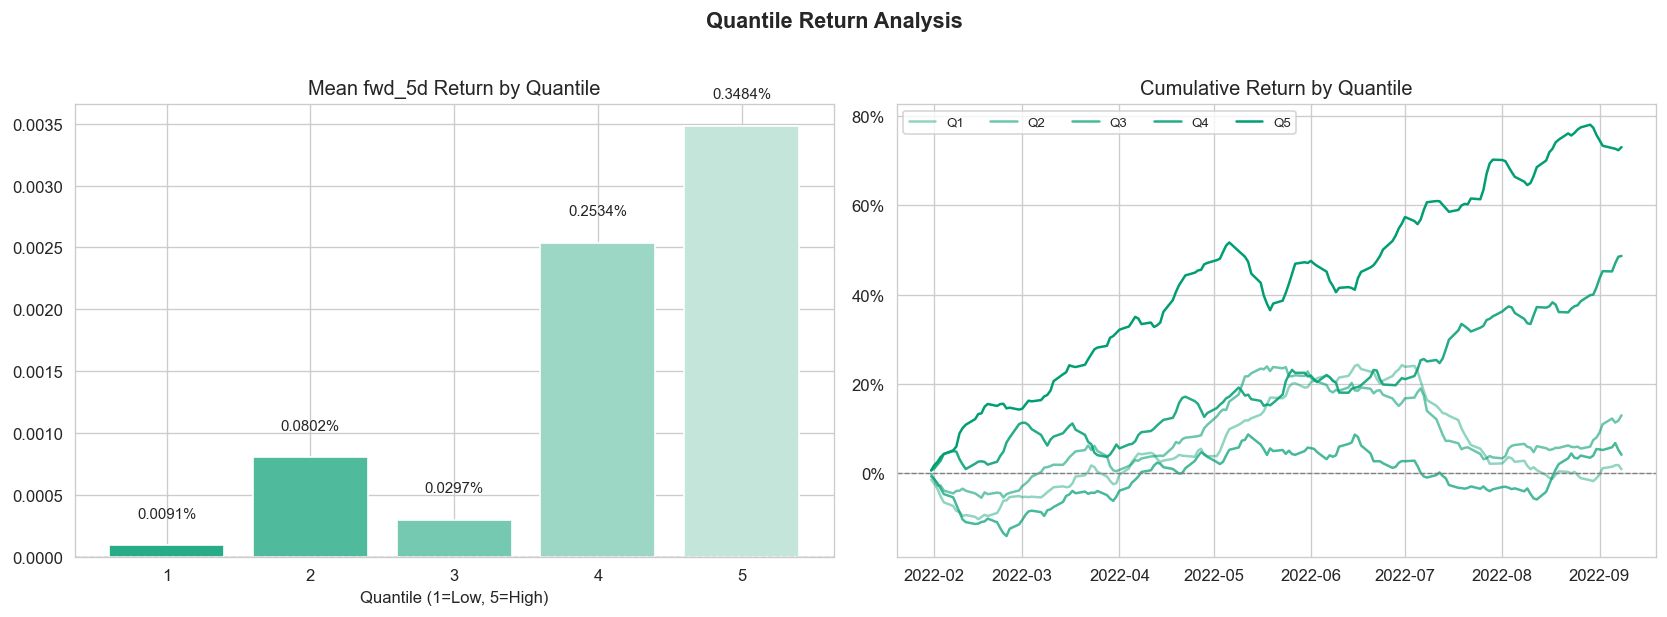

,mean_return,std_return,count,hit_rate
quantile,,,,
1,0.0001,0.0084,159,0.5157
2,0.0008,0.0084,159,0.5786
3,0.0003,0.0093,159,0.5094
4,0.0025,0.0089,159,0.6226
5,0.0035,0.0080,159,0.6855


In [6]:
# ── 分层收益 ──
valid = df[df.universe & df["quantile"].notna() & df[FWD_COL].notna()]

daily_q = (valid.groupby(["trade_date", "quantile"])[FWD_COL]
           .mean().reset_index().rename(columns={FWD_COL: "avg_return"}))

q_summary = (daily_q.groupby("quantile")["avg_return"]
             .agg(["mean", "std", "count"])
             .rename(columns={"mean": "mean_return", "std": "std_return"}))
q_summary["hit_rate"] = daily_q.groupby("quantile")["avg_return"].apply(
    lambda s: (s > 0).mean())

q_pivot = daily_q.pivot(index="trade_date", columns="quantile", values="avg_return")
q_cum = (1 + q_pivot.fillna(0)).cumprod() - 1

# ── 图表 ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 均收益柱状图
ax = axes[0]
colors = sns.light_palette(C[2], n_colors=N_QUANTILES + 2, reverse=True)[1:-1]
bars = ax.bar(q_summary.index.astype(str), q_summary["mean_return"],
              color=colors, edgecolor="white")
for bar, val in zip(bars, q_summary["mean_return"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002,
            f"{val:.4%}", ha="center", va="bottom", fontsize=9)
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_title(f"Mean {FWD_COL} Return by Quantile")
ax.set_xlabel("Quantile (1=Low, 5=High)")

# 累计分层收益
ax = axes[1]
for q in range(1, N_QUANTILES + 1):
    if q in q_cum.columns:
        alpha = 0.3 + 0.7 * (q / N_QUANTILES)
        ax.plot(q_cum.index, q_cum[q], color=C[2], alpha=alpha,
                linewidth=1.5, label=f"Q{q}")
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_title("Cumulative Return by Quantile")
ax.legend(ncol=5, fontsize=8)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

fig.suptitle("Quantile Return Analysis", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

display(q_summary)


---
## 4. 多空收益

把分层浓缩成最直观的视角：**Q5 多头 - Q1 空头**。

这是研究型纸面多空，不是正式策略回测（不考虑交易成本、涨跌停、融券约束）。

,value
metric,
mean_spread,0.0034
volatility,0.0125
win_rate,0.5786
cum_return,0.6926
max_drawdown,-0.2018
sharpe,0.2711


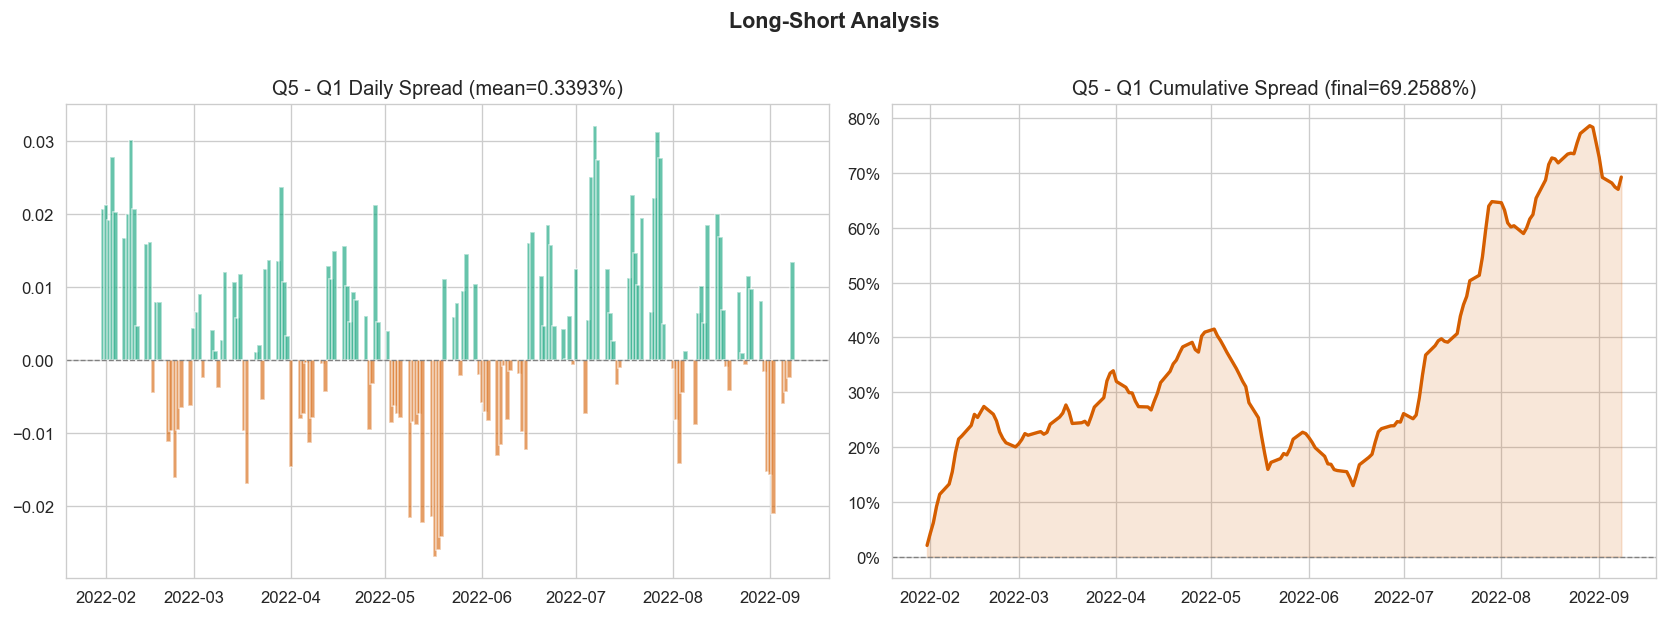

In [7]:
# ── 多空收益 ──
q5 = q_pivot.get(5, pd.Series(0, index=q_pivot.index))
q1 = q_pivot.get(1, pd.Series(0, index=q_pivot.index))
ls = pd.DataFrame({"trade_date": q_pivot.index, "spread": q5 - q1})
ls["cum_spread"] = (1 + ls["spread"].fillna(0)).cumprod() - 1

# 统计
s = ls["spread"].dropna()
cum = (1 + s).cumprod()
dd = (cum / cum.cummax() - 1)
ls_stats = pd.DataFrame({
    "metric": ["mean_spread", "volatility", "win_rate", "cum_return", "max_drawdown", "sharpe"],
    "value": [s.mean(), s.std(), (s > 0).mean(),
              ls["cum_spread"].iloc[-1], dd.min(),
              s.mean() / s.std() if s.std() > 0 else np.nan]
})
display(ls_stats.set_index("metric"))

# ── 图表 ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.bar(ls["trade_date"], ls["spread"],
       color=[C[2] if v >= 0 else C[3] for v in s], alpha=0.6, width=1.5)
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_title(f"Q5 - Q1 Daily Spread (mean={s.mean():.4%})")

ax = axes[1]
ax.plot(ls["trade_date"], ls["cum_spread"], color=C[3], linewidth=2)
ax.fill_between(ls["trade_date"], 0, ls["cum_spread"], color=C[3], alpha=0.15)
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_title(f'Q5 - Q1 Cumulative Spread (final={ls["cum_spread"].iloc[-1]:.4%})')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

fig.suptitle("Long-Short Analysis", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


---
## 5. 稳定性

单因子能不能持续，至少看三类东西：**IC 前后半段是否一致、因子值是否过于跳跃、分组换手率**。

,n,mean_ic,win_rate,ic_ir
period,,,,
Full,159,0.0320,0.5975,0.2914
First Half,79,0.0156,0.5570,0.1407
Second Half,80,0.0482,0.6375,0.4513


,value
metric,
mean_autocorr,0.9492
mean_turnover,0.3316


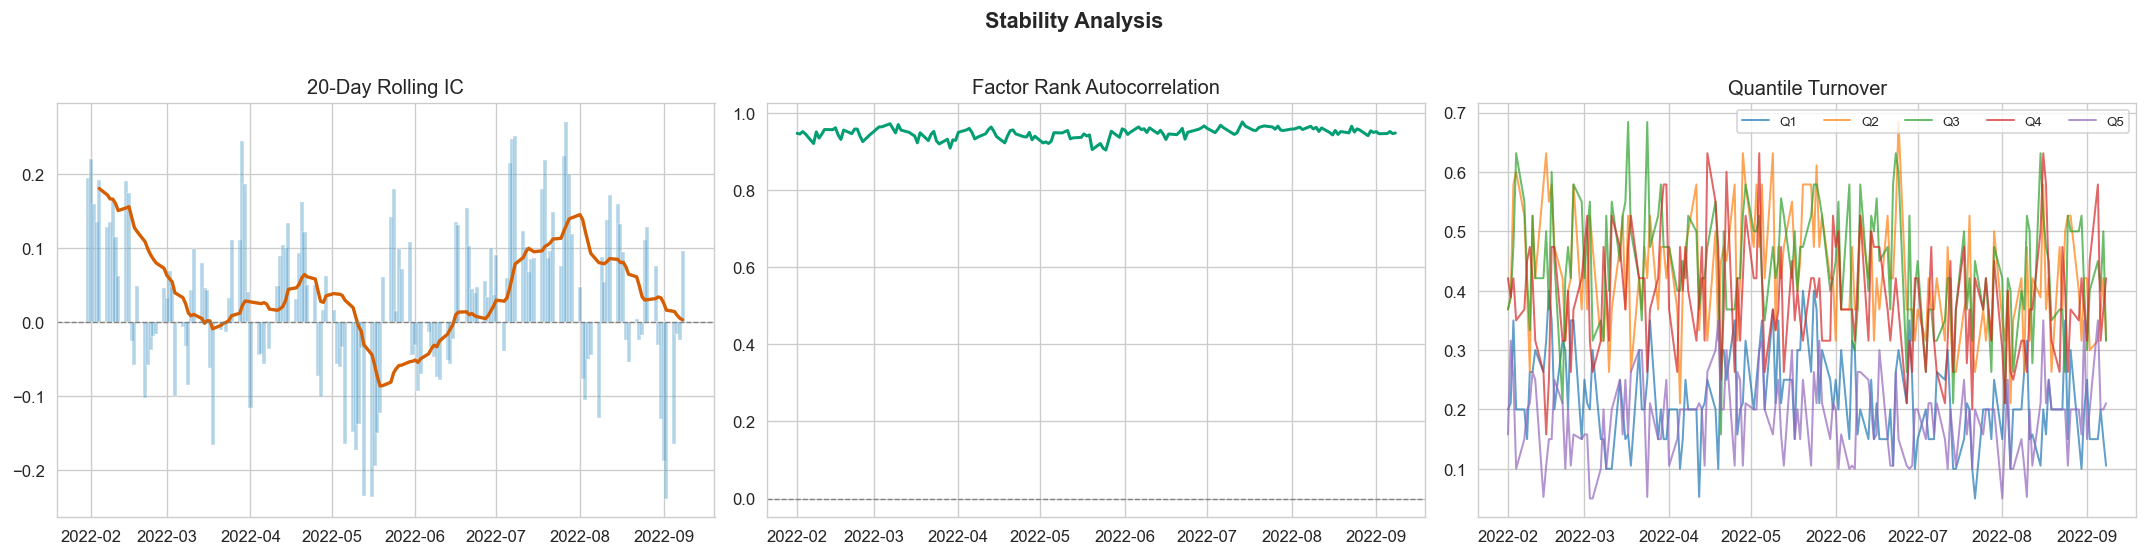

In [8]:
# ── 1) IC 前后半段对比 ──
mid = len(ic_df) // 2
half_stats = []
for label, part in [("Full", ic_df), ("First Half", ic_df.iloc[:mid]), ("Second Half", ic_df.iloc[mid:])]:
    ic = part["rank_ic"].dropna()
    half_stats.append({
        "period": label, "n": len(ic), "mean_ic": ic.mean(),
        "win_rate": (ic > 0).mean(),
        "ic_ir": ic.mean() / ic.std() if ic.std() > 0 else np.nan
    })
half_df = pd.DataFrame(half_stats)
display(half_df.set_index("period"))

# ── 2) 因子秩自相关 ──
dates = sorted(df[df.universe]["trade_date"].unique())
autocorr_rows = []
for d1, d2 in zip(dates[:-1], dates[1:]):
    prev = df[(df.trade_date == d1) & df.universe][["ts_code", FACTOR_COL]].rename(columns={FACTOR_COL: "f_prev"})
    curr = df[(df.trade_date == d2) & df.universe][["ts_code", FACTOR_COL]].rename(columns={FACTOR_COL: "f_curr"})
    m = prev.merge(curr, on="ts_code")
    if len(m) >= 10:
        autocorr_rows.append({"trade_date": d2, "autocorr": m["f_prev"].rank().corr(m["f_curr"].rank())})
autocorr_df = pd.DataFrame(autocorr_rows)

# ── 3) 分组换手率 ──
dates = sorted(df[df.universe & df["quantile"].notna()]["trade_date"].unique())
turnover_rows = []
for d1, d2 in zip(dates[:-1], dates[1:]):
    prev = df[(df.trade_date == d1) & df["quantile"].notna()]
    curr = df[(df.trade_date == d2) & df["quantile"].notna()]
    for q in range(1, N_QUANTILES + 1):
        p_set = set(prev[prev["quantile"] == q]["ts_code"])
        c_set = set(curr[curr["quantile"] == q]["ts_code"])
        if len(c_set) > 0:
            turnover_rows.append({"trade_date": d2, "quantile": q,
                                  "turnover": 1 - len(p_set & c_set) / len(c_set)})
turnover_df = pd.DataFrame(turnover_rows)
t_summary = turnover_df.groupby("quantile")["turnover"].mean().reset_index()
t_summary.columns = ["quantile", "avg_turnover"]

# 摘要
display(pd.DataFrame({
    "metric": ["mean_autocorr", "mean_turnover"],
    "value": [autocorr_df["autocorr"].mean(), turnover_df["turnover"].mean()]
}).set_index("metric"))

# ── 图表 ──
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

ax = axes[0]
ax.bar(ic_df["trade_date"], ic_df["rank_ic"], color=C[0], alpha=0.3, width=1.5)
ax.plot(ic_df["trade_date"], ic_df["rolling_20"], color=C[3], linewidth=2)
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_title("20-Day Rolling IC")

ax = axes[1]
ax.plot(autocorr_df["trade_date"], autocorr_df["autocorr"], color=C[2], linewidth=1.8)
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_title("Factor Rank Autocorrelation")

ax = axes[2]
for q in range(1, N_QUANTILES + 1):
    part = turnover_df[turnover_df["quantile"] == q]
    ax.plot(part["trade_date"], part["turnover"], linewidth=1.2, alpha=0.7, label=f"Q{q}")
ax.set_title("Quantile Turnover")
ax.legend(ncol=5, fontsize=8)

fig.suptitle("Stability Analysis", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


---
## 6. 总结

把各模块结论收成一张表。单个数字不够判断 — **IC + 分层单调性 + 多空 + 稳定性 要组合看**。

In [9]:
# ── 综合评分卡 ──
ic_mean = ic_df["rank_ic"].mean()
ic_win = (ic_df["rank_ic"] > 0).mean()
ls_mean = ls["spread"].mean()
ls_cum = ls["cum_spread"].iloc[-1]
auto_mean = autocorr_df["autocorr"].mean()
turnover_mean = turnover_df["turnover"].mean()

monotonic = q_summary["mean_return"].is_monotonic_increasing
q1_mean = q_summary.loc[1, 'mean_return']
q5_mean = q_summary.loc[N_QUANTILES, 'mean_return']

scorecard = pd.DataFrame([
    ["Mean IC", f"{ic_mean:.4f}", "OK" if ic_mean > 0 else "Weak"],
    ["IC Win Rate", f"{ic_win:.1%}", "OK" if ic_win > 0.5 else "Weak"],
    ["IC IR", f'{ic_mean / ic_df["rank_ic"].std():.3f}', "—"],
    ["Q1 -> Q5 Monotonic", "Yes" if monotonic else "No", "OK" if monotonic else "Check"],
    ["Q5 - Q1 Mean Spread", f"{ls_mean:.4%}", "OK" if ls_mean > 0 else "Weak"],
    ["LS Cumulative", f"{ls_cum:.4%}", "OK" if ls_cum > 0 else "Weak"],
    ["Rank Autocorr", f"{auto_mean:.3f}", "—"],
    ["Avg Turnover", f"{turnover_mean:.1%}", "—"],
], columns=["Metric", "Value", "Signal"])

display(scorecard.style.apply(lambda row: [
    "background-color: #e8f5e9" if row["Signal"] == "OK"
    else "background-color: #fff3e0" if row["Signal"] == "Weak"
    else "" for _ in row
], axis=1))

print(f"\n样本: {df.trade_date.nunique()} 交易日 x {df.ts_code.nunique()} 只股票"
      f" | 有效样本 {df.universe.sum():,} 条"
      f" | 因子: mom_{FACTOR_WINDOW}d | 主 horizon: {FWD_COL}")


,Metric,Value,Signal
0,Mean IC,0.0320,OK
1,IC Win Rate,59.7%,OK
2,IC IR,0.291,—
3,Q1 -> Q5 Monotonic,No,Check
4,Q5 - Q1 Mean Spread,0.3393%,OK
5,LS Cumulative,69.2588%,OK
6,Rank Autocorr,0.949,—
7,Avg Turnover,33.2%,—



样本: 200 交易日 x 100 只股票 | 有效样本 14,983 条 | 因子: mom_20d | 主 horizon: fwd_5d
